# Tutorial: Agentes baseados em objetivos e Métodos de Busca I

## Ajustando ambiente

In [22]:
%%capture

import matplotlib.pyplot as plt
import networkx as nx

## Motivação

O estudo de agentes baseados em objetivos e métodos de busca é fundamental na Inteligência Artificial, pois capacita os sistemas a planejarem com antecedência e a simularem sequências de ações que formam um caminho até um estado objetivo quando a atitude correta a ser tomada não é imediatamente óbvia. Nesse cenário, compreender a **busca não informada** é de extrema importância e forma o alicerce da resolução de problemas, já que essas estratégias operam sem qualquer conhecimento ou pista do domínio sobre a proximidade de um estado em relação ao objetivo. Ao estudar métodos não informados como a busca em largura, de custo uniforme e em profundidade, compreendemos como é possível explorar sistematicamente espaços de estados imensos ou infinitos de forma a garantir propriedades críticas, como a completude (encontrar uma solução se ela existir) e a otimização de custos. Além disso, a busca não informada nos força a lidar diretamente com o maior desafio da exploração de caminhos: a explosão combinatória e a complexidade de tempo e espaço. Estratégias não informadas, como a busca em profundidade e o aprofundamento iterativo, são consideradas as ferramentas de trabalho básicas em muitas áreas da IA justamente devido ao seu uso parcimonioso e inteligente da memória, ensinando-nos princípios essenciais de estruturas de dados e limites computacionais que preparam o terreno para atuar em ambientes desconhecidos e para o desenvolvimento de buscas heurísticas mais avançadas.

## Objetivos de Aprendizagem

* **Entender Agentes Baseados em Objetivos:** Compreender o conceito de agentes que formulam metas e buscam planos para alcançá-las.
* **Modelagem de Problemas:** Aprender a modelar problemas de busca, definindo estado inicial, objetivo, ações, transições e custos.
* **Compreender Métodos de Busca Não Informada:**
    * **Busca em Largura (BFS):** Entender como a BFS explora o espaço de estados nível por nível, suas propriedades de completude e otimalidade de custo.
    * **Busca em Profundidade (DFS):** Entender como a DFS explora o espaço de estados em profundidade, suas vantagens em uso de memória e suas limitações.
    * **Diferenças entre BFS e DFS:** Analisar as principais diferenças entre BFS e DFS em termos de estratégia de exploração, completude e otimalidade.
* **Implementação de Componentes do Agente:** Familiarizar-se com a estrutura de classes como `Problem`, `GraphProblem`, `Node`, `SimpleProblemSolvingAgentProgram` e `SearchAgent`.

## Implementação

### Classes do Ambiente

A classe `Problem` fornece a estrutura abstrata para descrever um problema de busca, definindo conceitos como estado inicial, objetivo, ações e transições e custo. No tutorial, ela ajuda a separar o **ambiente** da **forma como o agente raciocina sobre ele**.


In [23]:
class Problem:
    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        raise NotImplementedError
    
    def result(self, state, action):
        raise NotImplementedError
    
    def goal_test(self, state):
        return state == self.goal 

    def path_cost(self, c, state1, action, state2):
        return c + 1

A partir da classe anterior, vamos extender `GraphProblem` a qual especializa essa formulação para o caso em que o ambiente é um **grafo**.

In [24]:
class GraphProblem(Problem):
    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return list(self.graph.get(state).keys())

    def result(self, state, action):
        return action

    def path_cost(self, cost_so_far, state1, action, state2):
        edge_cost = self.graph.get(state1, state2)
        if edge_cost is None:
            return float('inf')
        return cost_so_far + edge_cost

Em seguida, definimos a classe `SimpleGraph` como uma estrutura auxiliar simples para representar o ambiente em forma de grafo, que será utilizada por GraphProblem.


In [25]:
class SimpleGraph:
    def __init__(self, graph_dict):
        self.graph_dict = graph_dict

    def get(self, a, b=None):
        links = self.graph_dict.setdefault(a, {})
        if b is None:
            return links
        return links.get(b)

Para solucionar o processo de busca em grafos, precisamos transformá-lo em uma árvore de busca. A classe `Node` representa um nó da árvore de busca. Ela guarda o estado atual, o pai, a ação usada para chegar ali e a profundidade. No tutorial, essa classe permite reconstruir o caminho encontrado pelo agente durante a etapa de simulação.

In [26]:
class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.depth = 0 if parent is None else parent.depth + 1

    def __repr__(self):
        return '<Node {}>'.format(self.state)

    def __lt__(self, node):
        return self.state < node.state

    def expand(self, problem):
        return [self.child_node(problem, action) for action in problem.actions(self.state)]

    def child_node(self, problem, action):
        next_state = problem.result(self.state, action)
        return Node(
            next_state,
            self,
            action,
            problem.path_cost(self.path_cost, self.state, action, next_state),
        )

    def solution(self):
        return [node.action for node in self.path()[1:]]

    def path(self):
        node = self
        path_back = []
        while node is not None:
            path_back.append(node)
            node = node.parent
        path_back.reverse()
        return path_back

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)

<details>
<summary>Explicação</summary>

1.  **`class Node:`**

> Define a estrutura do objeto que representará um estado dentro da **árvore de busca**. Diferente de um grafo puro, o nó da árvore armazena o histórico (rastro) de como o agente chegou até ali.

2.  **`def __init__(self, state, parent=None, action=None, path_cost=0):`**

> O construtor da classe. Ele inicializa os atributos fundamentais: o estado atual (`state`), o nó que o gerou (`parent`), a ação tomada para alcançá-lo (`action`) e o custo total acumulado do caminho (`path_cost`).

3.  **`self.depth = 0 if parent is None else parent.depth + 1`**

> Calcula automaticamente a profundidade do nó. Se não houver um pai, ele é a raiz (nível 0). Caso contrário, sua profundidade será a do pai somada a 1.

4.  **`def __repr__(self):`**

> Define a representação textual do objeto. Ao imprimir o nó ou vê-lo em uma lista, ele aparecerá formatado como `<Node Natal>`, facilitando o *debug*.

5.  **`def __lt__(self, node):`**

> Implementa o operador "menor que" (`less than`). Permite comparar dois nós (usando a ordem alfabética ou valor do estado), o que é essencial para algoritmos que organizam filas de prioridade.

6.  **`def expand(self, problem):`**

> Método que gera todos os nós sucessores possíveis. Ele utiliza uma *list comprehension* para varrer as ações disponíveis no `problem` e criar novos nós filhos.

7.  **`def child_node(self, problem, action):`**

> Cria um único nó filho específico. Ele solicita ao `problem` o resultado da ação (próximo estado) e calcula o novo custo total do caminho antes de instanciar o novo `Node`.

8.  **`def solution(self):`**

> Extrai a sequência de ações da raiz até o nó atual. Ele fatia a lista de caminho `[1:]` para ignorar o nó inicial, que não possui uma ação vinculada.

9.  **`def path(self):`**

> Reconstrói a trajetória completa. O método percorre os ponteiros de `parent` de volta até a raiz, armazena-os em uma lista e depois a inverte (`reverse`) para exibir a ordem cronológica da viagem.

10. **`def __eq__(self, other):`**

> Define o critério de igualdade. Dois nós são considerados iguais se forem do mesmo tipo e representarem o mesmo estado geográfico (ex: dois caminhos diferentes que terminam em "Pipa").

11. **`def __hash__(self):`**

> Torna o nó "mapeável". Isso permite que o objeto seja usado em conjuntos (`set`) para controle de estados visitados, evitando que o algoritmo entre em loops infinitos no mapa.

</details>


### Classes de Agente

As classes `SimpleProblemSolvingAgentProgram` e `SearchAgent` estão relacionadas à parte deliberativa do agente no tutorial. A classe `SimpleProblemSolvingAgentProgram` define a estrutura geral de um agente baseado em objetivos: ela descreve o ciclo de perceber o estado atual, formular um objetivo, formular um problema e buscar uma sequência de ações para alcançá-lo.

In [27]:
class SimpleProblemSolvingAgentProgram:
    def __init__(self, initial_state=None):
        self.state = initial_state
        self.seq = []

    def __call__(self, percept):
        self.state = self.update_state(self.state, percept)
        if not self.seq:
            goal = self.formulate_goal(self.state)
            problem = self.formulate_problem(self.state, goal)
            self.seq = self.search(problem)
            if not self.seq:
                return None
        return self.seq.pop(0)

    def update_state(self, state, percept):
        raise NotImplementedError

    def formulate_goal(self, state):
        raise NotImplementedError

    def formulate_problem(self, state, goal):
        raise NotImplementedError

    def search(self, problem):
        raise NotImplementedError

<details>
 <summary>O que é um Problem-solving Agent?</summary>
O *problem-solving agent* (agente de resolução de problemas) é um agente baseado em objetivo. Quando a ação correta a ser tomada não é imediatamente óbvia, esse tipo de agente precisa planejar com antecedência, avaliando uma sequência de ações que formam um caminho até um **estado objetivo**.

Uma característica fundamental desses agentes é o uso de **representações atômicas**, o que significa que eles encaram os estados do mundo como um todo indivisível, sem que nenhuma estrutura interna seja visível aos algoritmos envolvidos na resolução do problema. Caso o agente utilize representações fatoradas ou estruturadas dos estados para alcançar suas metas, ele é classificado de forma diferente, sendo chamado de agente de planejamento (*planning agent*).
</details>

A classe `SearchAgent` é uma implementação concreta dessa ideia, pois especializa essa estrutura para um ambiente representado por grafo e delega a geração do plano a um método de busca específico, como busca em largura ou busca em profundidade. Assim, a primeira classe fornece o modelo abstrato de raciocínio do agente, enquanto a segunda mostra como esse modelo pode ser instanciado na prática dentro do contexto do tutorial.

In [28]:
class SearchAgent(SimpleProblemSolvingAgentProgram):
    def __init__(self, goal, search_algorithm, graph):
        super().__init__(initial_state=None)
        self.goal = goal
        self.search_algorithm = search_algorithm
        self.graph = graph

    def update_state(self, state, percept):
        return percept

    def formulate_goal(self, state):
        return self.goal

    def formulate_problem(self, state, goal):
        return GraphProblem(state, goal, self.graph)

    def search(self, problem):
        node = self.search_algorithm(problem)
        if node is None:
            return []
        return node.solution()

### Funções Auxiliares

In [29]:
def state_path(node):
    if node is None:
        return None
    return [step.state for step in node.path()]

def verbose(node):
    if node is None:
        return {
            'encontrou': False,
            'caminho': None,
            'acoes': None,
            'custo': None,
        }
    return {
        'encontrou': True,
        'caminho': state_path(node),
        'acoes': node.solution(),
        'custo': node.path_cost,
    }

def agent_simulation(agent, initial_state, max_step=20):
    state = initial_state
    trajectory = [state]
    actions = []

    for _ in range(max_step):
        action = agent(state)
        if action is None:
            break

        actions.append(action)
        state = action
        trajectory.append(state)

        if state == agent.goal:
            break

    return actions, trajectory

## Exemplo prático

Agora vamos aplicar essas estruturas em um ambiente simples, com um estado inicial `A` e um objetivo `P`.

### Construção do Ambiente

In [30]:
environment = {
    'Natal': {'Parnamirim': 1, 'Extremoz': 1, 'São Gonçalo do Amarante': 1, 'Macaíba': 1},
    'Parnamirim': {'Natal': 1, 'São José de Mipibu': 1, 'Macaíba': 1},
    'Extremoz': {'Natal': 1},
    'São Gonçalo do Amarante': {'Natal': 1, 'Macaíba': 1, 'Ceará-Mirim': 1},
    'Macaíba': {'Natal': 1, 'Parnamirim': 1, 'São Gonçalo do Amarante': 1, 'Ielmo Marinho': 1, 'Vera Cruz': 1},
    'Ceará-Mirim': {'São Gonçalo do Amarante': 1},
    'Ielmo Marinho': {'Macaíba': 1},
    'Vera Cruz': {'Macaíba': 1, 'Monte Alegre': 1},
    'Monte Alegre': {'Vera Cruz': 1, 'São José de Mipibu': 1},
    'São José de Mipibu': {'Parnamirim': 1, 'Goianinha': 1, 'Monte Alegre': 1},
    'Goianinha': {'São José de Mipibu': 1, 'Tibau do Sul': 1},
    'Tibau do Sul': {'Goianinha': 1, 'Pipa': 1},
    'Pipa': {'Tibau do Sul': 1}
}

In [31]:
graph = SimpleGraph(environment)
problem = GraphProblem('Natal', 'Pipa', graph)

print('Estado inicial:', problem.initial)
print('Objetivo:', problem.goal)
print('Ações possíveis em Natal:', problem.actions('Natal'))

Estado inicial: Natal
Objetivo: Pipa
Ações possíveis em Natal: ['Parnamirim', 'Extremoz', 'São Gonçalo do Amarante', 'Macaíba']


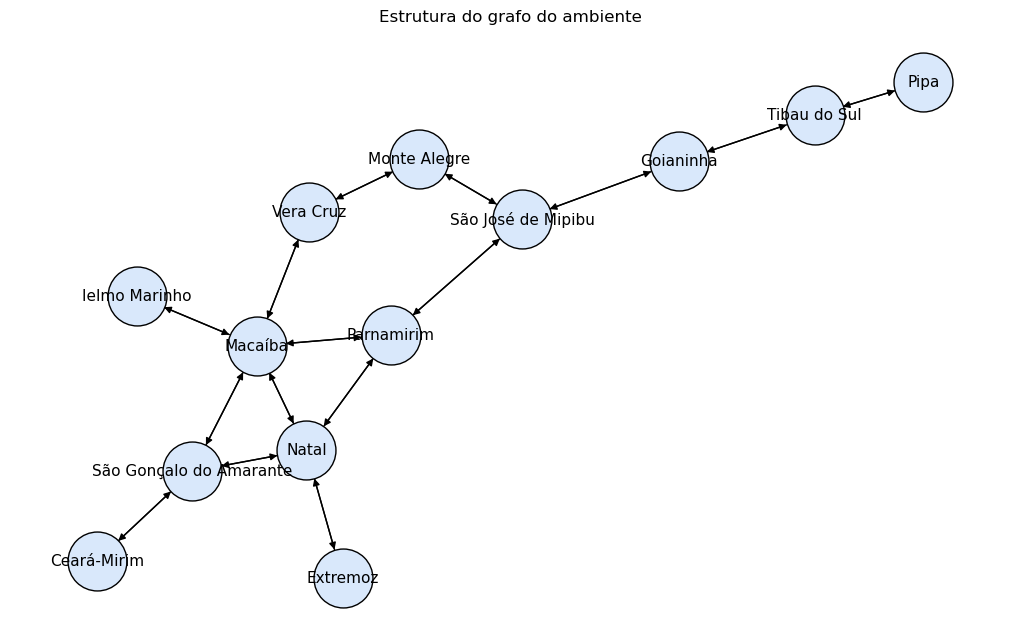

In [32]:
# @title Estrutura do grafo
G = nx.DiGraph()
for origem, destinos in environment.items():
    for destino in destinos:
        G.add_edge(origem, destino)

pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(10, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='#d9e8fb',
    node_size=1800,
    arrows=True,
    font_size=11,
    edgecolors='black'
)
plt.title('Estrutura do grafo do ambiente')
plt.show()

### Busca em largura

A busca em largura é uma estratégia de busca na qual o nó raiz é expandido primeiro, seguido por todos os seus nós sucessores, depois os sucessores destes, e assim por diante, explorando o espaço de estados nível por nível. O algoritmo geralmente utiliza uma estrutura de dados do tipo fila FIFO (primeiro a entrar, primeiro a sair), o que garante que os nós recém-gerados (mais profundos) vão para o final da fila e os nós mais antigos e rasos sejam expandidos primeiro. Por explorar todas as opções de uma profundidade antes de avançar para a próxima, a busca em largura é sistemática, completa e garante encontrar uma solução com o número mínimo de ações necessárias.

In [33]:
def breadth_first_graph_search(problem, return_expansion_order=False):
    node = Node(problem.initial)
    if problem.goal_test(node.state):
        if return_expansion_order:
            return node, [node.state]
        return node

    frontier = [node]
    visited = set()
    expansion_order = []

    while frontier:
        node = frontier.pop(0)
        expansion_order.append(node.state)
        visited.add(node.state)

        for child in node.expand(problem):
            if child.state not in visited and child not in frontier:
                if problem.goal_test(child.state):
                    expansion_order.append(child.state)
                    if return_expansion_order:
                        return child, expansion_order
                    return child
                frontier.append(child)

    if return_expansion_order:
        return None, expansion_order
    return None


<details>
<summary>Explicação</summary>

1.  **`def breadth_first_graph_search(problem, return_expansion_order=False):`**

> Define a função de busca em largura no grafo. O parâmetro `return_expansion_order` permite que, além do resultado, a função retorne a lista de cidades na ordem em que foram "visitadas" pelo algoritmo.

2.  **`node = Node(problem.initial)`**

> Cria o nó raiz da árvore de busca usando o estado inicial definido no problema (ex: `'Natal'`).

3.  **`if problem.goal_test(node.state):`**

> Verifica imediatamente se o ponto de partida já é o destino final (o objetivo). Se for, a busca termina sem nem começar.

4.  **`frontier = [node]`**

> Inicializa a **fronteira** (ou borda) como uma fila (FIFO - *First-In, First-Out*). Na busca em largura, a fronteira garante que exploraremos todos os vizinhos de um nível antes de passar para o próximo.

5.  **`visited = set()` e `expansion_order = []`**

> `visited` é um conjunto que armazena estados já explorados para evitar ciclos infinitos (ex: ficar indo e voltando entre Natal e Macaíba). `expansion_order` registra a sequência cronológica da exploração.

6.  **`while frontier:`**

> Inicia o laço principal que continuará executando enquanto houver cidades na fronteira para serem exploradas.

7.  **`node = frontier.pop(0)`**

> Remove e retorna o **primeiro** elemento da fila. Esse comportamento de "tirar do início" é o que caracteriza a busca em largura, priorizando os nós mais rasos da árvore.

8.  **`visited.add(node.state)`**

> Adiciona a cidade atual ao conjunto de visitados, marcando que já verificamos todos os vizinhos deste local.

9.  **`for child in node.expand(problem):`**

> Expande o nó atual, gerando novos nós para todas as cidades vizinhas conectadas a ele (ex: de Natal, gera Parnamirim, Extremoz, etc.).

10. **`if child.state not in visited and child not in frontier:`**

> Filtro de segurança: só processa o vizinho se ele ainda não foi visitado e se já não estiver na fila para ser visitado. Isso economiza memória e tempo.

11. **`if problem.goal_test(child.state):`**

> O "teste de objetivo" é feito no momento em que o nó filho é gerado. Se o vizinho for o destino (ex: `'Pipa'`), a busca é interrompida com sucesso.

12. **`frontier.append(child)`**

> Se o vizinho não for o destino, ele é adicionado ao **final** da fila da fronteira para ser explorado posteriormente, após os seus "irmãos".

13. **`return None`**

> Se a fila da fronteira esvaziar e o objetivo não tiver sido encontrado, a função retorna `None`, indicando que não há caminho possível entre as cidades no mapa fornecido.

</details>

In [34]:
resultado_bfs, expansoes_bfs = breadth_first_graph_search(problem, return_expansion_order=True)
print('BFS didática:', verbose(resultado_bfs))
print('Ordem de expansão BFS:', expansoes_bfs)

BFS didática: {'encontrou': True, 'caminho': ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'acoes': ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'custo': 5}
Ordem de expansão BFS: ['Natal', 'Parnamirim', 'Extremoz', 'São Gonçalo do Amarante', 'Macaíba', 'São José de Mipibu', 'Ceará-Mirim', 'Ielmo Marinho', 'Vera Cruz', 'Goianinha', 'Monte Alegre', 'Tibau do Sul', 'Pipa']


### Busca em profundidade

A busca em profundidade é uma estratégia que expande sempre o nó mais profundo disponível na fronteira de busca. O algoritmo avança imediatamente para o nível mais profundo da árvore e, ao alcançar um nó sem sucessores, ele "retrocede" para o próximo nó mais profundo que ainda possui opções não exploradas. Geralmente implementada com uma estrutura de dados do tipo pilha (último a entrar, primeiro a sair), essa abordagem destaca-se pelo uso muito reduzido de memória. Contudo, ao contrário da busca em largura, ela não garante encontrar a solução de menor custo e pode ser incompleta em espaços de estados infinitos, pois corre o risco de ficar presa indefinidamente em um único caminho.

In [35]:
def depth_first_graph_search(problem, return_expansion_order=False):
    frontier = [Node(problem.initial)]
    visited = set()
    expansion_order = []

    while frontier:
        node = frontier.pop()
        expansion_order.append(node.state)

        if problem.goal_test(node.state):
            if return_expansion_order:
                return node, expansion_order
            return node

        visited.add(node.state)
        for child in node.expand(problem):
            if child.state not in visited and child not in frontier:
                frontier.append(child)

    if return_expansion_order:
        return None, expansion_order
    return None


<details>
<summary>Explicação</summary>

1.  **`def depth_first_graph_search(problem, return_expansion_order=False):`**

> Define a função de busca em profundidade no grafo. O objetivo aqui é explorar um ramo completo da árvore de estados até o fim antes de tentar um caminho alternativo.

2.  **`frontier = [Node(problem.initial)]`**

> Inicializa a **fronteira** com o nó inicial (ex: `'Natal'`). Diferente da BFS, aqui a lista será tratada como uma **Pilha** (LIFO - *Last-In, First-Out*).

3.  **`visited = set()` e `expansion_order = []`**

> Prepara o conjunto `visited` para rastrear cidades já processadas e a lista `expansion_order` para registrar a ordem em que os nós são retirados da fronteira.

4.  **`while frontier:`**

> Mantém o loop ativo enquanto houver cidades na pilha da fronteira para serem exploradas.

5.  **`node = frontier.pop()`**

> Remove e retorna o **último** elemento adicionado à lista. Esse é o "pulo do gato" da DFS: ao pegar sempre o último, o algoritmo mergulha verticalmente no grafo em vez de expandir horizontalmente.

6.  **`expansion_order.append(node.state)`**

> Registra a cidade que acaba de ser retirada da pilha para análise na lista de ordem de expansão.

7.  **`if problem.goal_test(node.state):`**

> Realiza o teste de objetivo. Na DFS, o teste é feito apenas quando o nó é **retirado** da fronteira (pop), e não quando é gerado. Se for o destino (ex: `'Pipa'`), a busca para.

8.  **`visited.add(node.state)`**

> Marca o estado atual como visitado para garantir que o algoritmo não entre em *looping* caso encontre caminhos cíclicos no mapa do RN.

9.  **`for child in node.expand(problem):`**

> Gera os vizinhos da cidade atual. Se estivermos em Macaíba, ele gerará Vera Cruz, Ielmo Marinho, etc.

10. **`if child.state not in visited and child not in frontier:`**

> Verifica se o vizinho já foi explorado ou se já está aguardando na pilha. Isso evita redundância e processamento desnecessário.

11. **`frontier.append(child)`**

> Adiciona o nó filho ao **topo** da pilha. Como ele foi o último a entrar, será o primeiro a ser retirado no próximo ciclo do `while`, forçando a exploração profunda.

12. **`return None`**

> Se a pilha esvaziar e o objetivo nunca tiver sido alcançado, a função retorna `None`, indicando que o destino é inacessível a partir da origem.

</details>


In [36]:
resultado_dfs, expansoes_dfs = depth_first_graph_search(problem, return_expansion_order=True)
print('DFS didática:', verbose(resultado_dfs))
print('Ordem de expansão DFS:', expansoes_dfs)

DFS didática: {'encontrou': True, 'caminho': ['Natal', 'Macaíba', 'Vera Cruz', 'Monte Alegre', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'acoes': ['Macaíba', 'Vera Cruz', 'Monte Alegre', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'custo': 7}
Ordem de expansão DFS: ['Natal', 'Macaíba', 'Vera Cruz', 'Monte Alegre', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']


### Simulação do Agente

In [37]:
agente_bfs = SearchAgent(goal = 'Pipa', search_algorithm = breadth_first_graph_search, graph = graph)
actions_bfs, trajetoria_bfs = agent_simulation(agente_bfs, 'Natal')

print('Agente com BFS')
print('Ações:', actions_bfs)
print('Trajetória:', trajetoria_bfs)

Agente com BFS
Ações: ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Trajetória: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']


In [38]:
agente_dfs = SearchAgent(goal='Pipa', search_algorithm=depth_first_graph_search, graph=graph)
actions_dfs, trajetoria_dfs = agent_simulation(agente_dfs, 'Natal')

print('Agente com DFS')
print('Ações:', actions_dfs)
print('Trajetória:', trajetoria_dfs)

Agente com DFS
Ações: ['Macaíba', 'Vera Cruz', 'Monte Alegre', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Trajetória: ['Natal', 'Macaíba', 'Vera Cruz', 'Monte Alegre', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']


## Desafio

Implemente uma versão da **busca em profundidade limitada**. Nessa estratégia, a exploração segue em profundidade, mas o algoritmo só pode expandir nós até uma profundidade máxima definida por `limit`.

Sua função deve:

1. Começar no estado inicial do problema;
2. Explorar os nós em profundidade;
3. Impedir a expansão de nós com profundidade maior ou igual ao limite;
4. Retornar o nó solução se encontrar o objetivo;
5. Retornar `None` se nenhuma solução for encontrada dentro do limite.

Use o atributo `node.depth` para controlar a expansão.

In [39]:
def depth_limited_search(problem, limit=2):
    # Comece com o nó inicial na fronteira.
    frontier = [Node(problem.initial)]

    limit = 5
    
    while frontier:
        node = frontier.pop()

        # Verifique se o objetivo foi encontrado.
        if problem.goal_test(node.state):
            return node

        # Expanda o nó apenas se ele ainda estiver dentro do limite.
        if node.depth < limit:
            for child in node.expand(problem):
                # Adicione os filhos à fronteira.
                pass

    return None

## Key takeways

- Um agente baseado em objetivos precisa formular um problema antes de buscar uma solução.
- BFS e DFS usam a mesma modelagem do problema, mas exploram o espaço de estados de formas diferentes.
- A solução pode ser representada como uma sequência de ações obtida a partir de um `Node`.
- Separar ambiente, problema e agente torna o código mais reutilizável.

## Referencias

1. Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern Approach. Prentice Hall.
2. Implementações clássicas de `Problem`, `Node` e agentes baseados em objetivos no ecossistema AIMA.